Workshop-2


In [18]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score


In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
#1. Softmax Function
def softmax(z):

    z_stable = z - np.max(z, axis=1, keepdims=True)

    exp_z = np.exp(z_stable)

    probs = exp_z / np.sum(exp_z, axis=1, keepdims=True)

    return probs


In [21]:
#2. Prediction Function
def predict_softmax(X, W, b):

    z = np.dot(X, W) + b

    probs = softmax(z)

    predicted_classes = np.argmax(probs, axis=1)

    return predicted_classes

In [22]:
#3. Cross Entropy Loss Function
def loss_softmax(y_pred, y):

    n = y.shape[0]

    loss = -np.sum(y * np.log(y_pred + 1e-15)) / n

    return loss

In [23]:
#4. Cost Function
def cost_softmax(X, y, W, b):

    n = X.shape[0]

    z = np.dot(X, W) + b

    y_pred = softmax(z)

    total_loss = -np.sum(y * np.log(y_pred + 1e-15))

    return total_loss / n

In [24]:
#5. Compute Gradient
def compute_gradient_softmax(X, y, W, b):

    n = X.shape[0]

    z = np.dot(X, W) + b

    y_pred = softmax(z)

    grad_W = np.dot(X.T, (y_pred - y)) / n

    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b


In [25]:
#6. Gradient Descent
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):

    cost_history = []

    for i in range(n_iter):

        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        W = W - alpha * grad_W

        b = b - alpha * grad_b

        cost = cost_softmax(X, y, W, b)

        cost_history.append(cost)

        if show_cost and i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost}")

    return W, b, cost_history

In [26]:
#7. Plot Sample Images
def plot_sample_images(X, y):

    plt.figure(figsize=(10,4))

    unique_classes = np.unique(y)

    for i, digit in enumerate(unique_classes):

        index = np.where(y == digit)[0][0]

        image = X[index].reshape(28,28)

        plt.subplot(2,5,i+1)

        plt.imshow(image, cmap='gray')

        plt.title(f"Digit: {digit}")

        plt.axis('off')

    plt.tight_layout()

    plt.show()

In [27]:
#8. Load and Prepare MNIST Dataset
def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):

    df = pd.read_csv(csv_file)

    y = df.iloc[:,0].values

    X = df.iloc[:,1:].values

    X = X / 255.0

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    plot_sample_images(X, y)

    return X_train, X_test, y_train, y_test

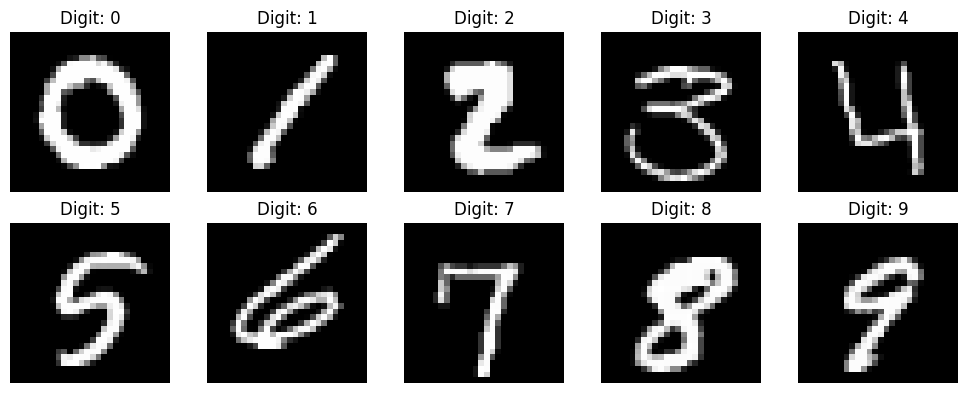

In [28]:
file_path = '/content/drive/MyDrive/AI and Machine Learning/dataset2/mnist_train.csv'

X_train, X_test, y_train, y_test = load_and_prepare_mnist(file_path)

In [29]:
#10. One-Hot Encoding
encoder = OneHotEncoder(sparse_output=False)

y_train = encoder.fit_transform(y_train.reshape(-1,1))

y_test = encoder.transform(y_test.reshape(-1,1))


In [30]:
#11. Initialize Model Parameters
d = X_train.shape[1]

c = y_train.shape[1]

W = np.random.randn(d, c) * 0.01

b = np.zeros(c)

alpha = 0.1

n_iter = 1000


In [31]:
#12. Train the Model
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha, n_iter, show_cost=True
)

Iteration 0, Cost: 2.216373744036903
Iteration 100, Cost: 0.600397912946095
Iteration 200, Cost: 0.4819964712605833
Iteration 300, Cost: 0.4327815807675674
Iteration 400, Cost: 0.4042410766991787
Iteration 500, Cost: 0.38501769608896846
Iteration 600, Cost: 0.37091193950154033
Iteration 700, Cost: 0.3599708666315129
Iteration 800, Cost: 0.3511485222410324
Iteration 900, Cost: 0.34382788354621896


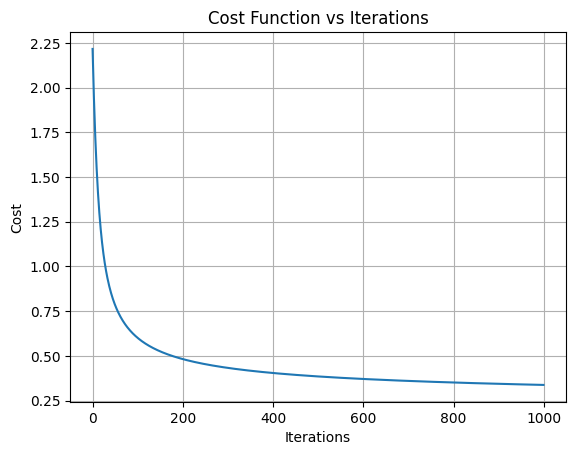

In [32]:
#13. Plot Cost vs Iterations
plt.plot(cost_history)

plt.title("Cost Function vs Iterations")

plt.xlabel("Iterations")

plt.ylabel("Cost")

plt.grid(True)

plt.show()

In [33]:
#14. Evaluation Function
def evaluate_classification(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    precision = precision_score(y_true, y_pred, average='weighted')

    recall = recall_score(y_true, y_pred, average='weighted')

    f1 = f1_score(y_true, y_pred, average='weighted')

    return cm, precision, recall, f1

In [34]:
#15. Model Evaluation
y_pred_test = predict_softmax(X_test, W_opt, b_opt)

y_test_labels = np.argmax(y_test, axis=1)

cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

print("\nConfusion Matrix:")

print(cm)

print("Precision:", precision)

print("Recall:", recall)

print("F1 Score:", f1)


Confusion Matrix:
[[779   0   1   1   3  12   8   0  11   1]
 [  0 889   2   1   1   2   2   2   9   1]
 [  6  10 738  11  26   2  11  16  25   1]
 [  2   5  26 800   1  41   6  11  27  18]
 [  1   1   7   2 774   4  11   2   2  35]
 [ 10   6   5  25  15 586  23   4  20   8]
 [  7   1   7   3   6   9 741   1   9   1]
 [  1  12  16   3  14   4   0 801   2  40]
 [  2  11   9  27   7  23   8   7 729  12]
 [  6   3   6  16  23   7   0  30   6 741]]
Precision: 0.9020669075618124
Recall: 0.9021428571428571
F1 Score: 0.9019038921681266


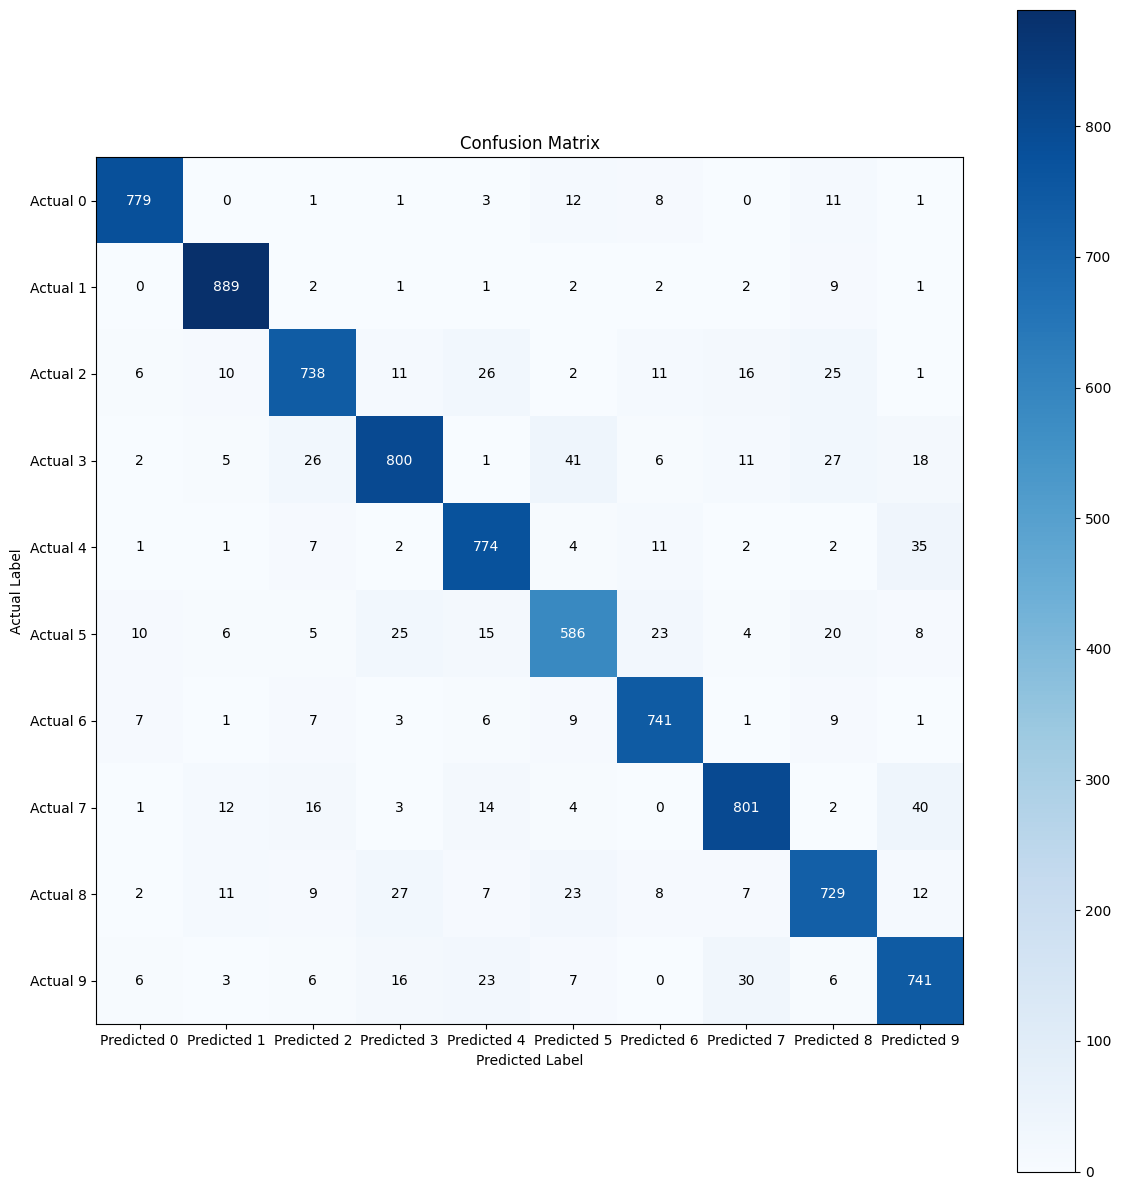

In [35]:
#16. Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(12,12))

cax = ax.imshow(cm, cmap='Blues')

num_classes = cm.shape[0]

ax.set_xticks(range(num_classes))

ax.set_yticks(range(num_classes))

ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)])

ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha='center', va='center',
                color='white' if cm[i,j] > np.max(cm)/2 else 'black')

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.colorbar(cax)

plt.tight_layout()

plt.show()

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

# Linearly separable
X_linear, y_linear = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_linear, y_linear, test_size=0.2, random_state=42)
model_l = LogisticRegression().fit(X_train_l, y_train_l)

# Non-linear (circles)
X_circles, y_circles = make_circles(n_samples=200, noise=0.1, factor=0.5, random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_circles, y_circles, test_size=0.2, random_state=42)
model_c = LogisticRegression().fit(X_train_c, y_train_c)

def plot_decision_boundary(ax, model, X, y, title):
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X